In [1]:
### Notebook to produce the plot showing corr in clin data 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl

(414, 38)


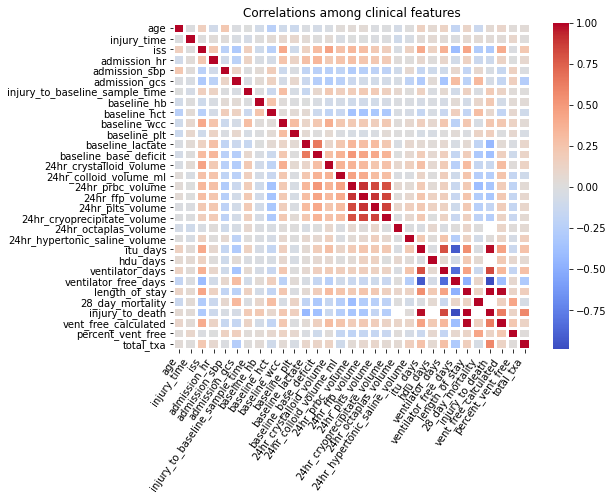

In [27]:
clin = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
print(clin.shape)

# plot full data correlation
plt.figure(figsize = (8,6))
correlation = clin.corr()
ax = sns.heatmap(data=correlation, 
                 cmap='coolwarm', 
                 linewidths=2, 
                 cbar=True)
plt.title("Correlations among clinical features")
plt.xticks(rotation = 55, ha='right')

plt.savefig("/Users/smasarone/Documents/jupyter_notebooks_copy2/EDA_corr_heatmap_full.pdf", format="pdf", bbox_inches="tight") 


In [8]:
# preprocessing 
list_groups = []
for i in clin['iss']:
    if i<=3:
        list_groups.append("Control")
    elif i>3 and i<= 8:
        list_groups.append("Low")
    elif i>=9 and i<=15:
        list_groups.append("Moderate")
    elif i>15 and i<25:
        list_groups.append("Severe")
    else:
        list_groups.append("Critical")

groups = pd.DataFrame(list_groups, columns  = (['Severity']))
groups = groups.set_index(clin.index)
clin =  clin.join(groups)

#drop no needed columns
clin =  clin.drop(labels= ['inf','admission_time','injury_date','injury_to_baseline_sample_time', 'injury_date_time', 'injury_to_death','24hr_crystalloid_volume',
       '24hr_colloid_volume_ml', '24hr_prbc_volume', '24hr_ffp_volume','24hr_plts_volume', '24hr_cryoprecipitate_volume','24hr_octaplas_volume', 
       '24hr_hypertonic_saline_volume', 'itu_days','hdu_days', 'ventilator_days', 'ventilator_free_days', 'length_of_stay','28_day_mortality', 
       'vent_free_calculated', 'percent_vent_free','injury_type', 'total_txa','Severity'], axis = 1)

categorical_feature_mask = clin.dtypes==object
categorical_cols = clin.columns[categorical_feature_mask].tolist()
le = LabelEncoder()
clin[categorical_cols] = clin[categorical_cols].apply(lambda col: le.fit_transform(col))
clin.fillna(0, inplace=True) 

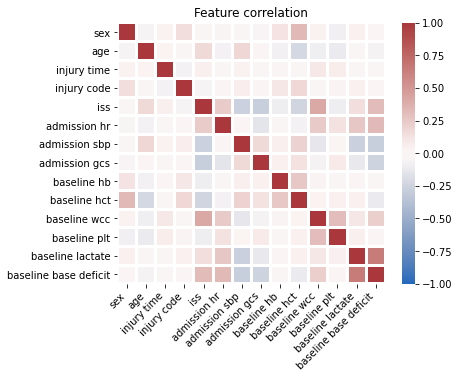

In [9]:
# make a smaller version only using some of the data
plt.figure(figsize = (6,4.8))
correlation = clin.corr()

new_col=[]
for i in correlation.columns:
    new = i.replace("_", " ")
    new_col.append(new)

correlation.columns = new_col
correlation.index = new_col
norm = mpl.colors.Normalize(vmin=-1, vmax=1)
ax = sns.heatmap(data=correlation, cmap='vlag', 
                 linewidths=2, 
                 cbar=True, 
                 norm = norm)
plt.title("Feature correlation")
plt.xticks(rotation = 45, 
           ha='right') 

plt.savefig("/Users/smasarone/Documents/jupyter_notebooks_copy2/EDA_corr_heatmap.pdf", format="pdf", bbox_inches="tight") 

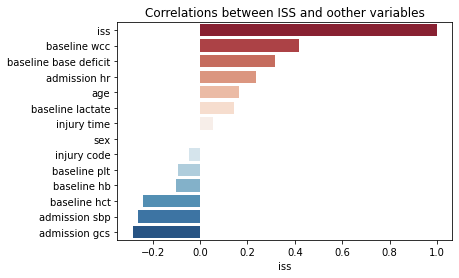

In [26]:
# make a correlation plot to show the ones strictly associated to iss
plt.title('Correlations between ISS and oother variables')
sns.barplot(x = correlation['iss'].sort_values(ascending=False), y = correlation['iss'].sort_values(ascending=False).index, palette = 'RdBu')
plt.savefig("/Users/smasarone/Documents/jupyter_notebooks_copy2/corr_with_ISS.pdf", format="pdf", bbox_inches="tight") 